# PC Tutorial: Two-Prior RSG Smoke Track

This notebook is an onboarding artifact for the predictive-coding (PC) track only. It explains the project framing, task, conceptual monkey-data target, PC model mechanism, validation story, and the real saved seed-0 diagnostics currently on disk.

It does not retrain, run neural-data ingestion, run BPTT, or make RSA/iDSA claims.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'AGENTS.md').exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.conditions import CONDITIONS, EFFECTORS, OVERLAP_TS_MS, PRIORS, TS_BY_PRIOR
from src.store import ActivationStore
from src.task.rsg import build_trial, trial_target_and_mask
from src.training.config import Config

RUN_DIR = ROOT / 'results' / 'runs' / 'pc' / 'seed_0000'
FIG_DIR = ROOT / 'results' / 'figures'
PC_FIG_DIR = FIG_DIR / 'pc_activity'
METRICS_PATH = RUN_DIR / 'metrics.json'
CONFIG_PATH = RUN_DIR / 'config.yaml'
STORE_ROOT = RUN_DIR / 'activations'

assert METRICS_PATH.exists(), f'missing {METRICS_PATH}'
assert CONFIG_PATH.exists(), f'missing {CONFIG_PATH}'

metrics = json.loads(METRICS_PATH.read_text())
cfg = Config.from_yaml(CONFIG_PATH)
store = ActivationStore(STORE_ROOT)
records = {cond: store.read(cfg.rule, cfg.seed, cond) for cond in CONDITIONS if store.has(cfg.rule, cfg.seed, cond)}

print(f'run_dir: {RUN_DIR.relative_to(ROOT)}')
print(f'rule={cfg.rule!r}, seed={cfg.seed}, config n_iter={cfg.n_iter}, metrics n_iter={metrics.get("n_iter")}')
print(f'activation records: {len(records)}/{len(CONDITIONS)}')
print(f'finite_loss={metrics.get("finite_loss")}, valid_tp_count={metrics.get("valid_tp_count")}')

run_dir: results\runs\pc\seed_0000
rule='pc', seed=0, config n_iter=3000, metrics n_iter=3000
activation records: 20/20
finite_loss=True, valid_tp_count=0


## 1. Project framing

The project asks whether the learning rule leaves a measurable signature on latent geometry and dynamics in the two-prior Ready-Set-Go task, and whether a PC-trained network sits closer to macaque DMFC than a BPTT-trained network when architecture is held fixed.

The root project governance makes two standards load-bearing:

> "Architecture is held fixed across the two, so any difference is attributable to the rule rather than the architecture."

> "Latents that were not preprocessed identically cannot be compared, and a single network per condition is not a result."

> "Seeds are the unit of evidence."

> "Behavior is measured, never a filter."

This notebook is not a final result because it shows one PC seed only. Its purpose is narrower: make the current PC mechanism and smoke-run diagnostics inspectable without smoothing over the unresolved parts.

## 2. The RSG task

The condition schema is defined once in `src.conditions`: `prior x ts x effector`, with 20 modeled comparison conditions. The short prior supports `[480, 560, 640, 720, 800]` ms and the long prior supports `[800, 900, 1000, 1100, 1200]` ms. The shared `800 ms` interval is the identifiability point: the same sample interval appears under both priors.

Each model input has three channels:

- Ready/Set pulse channel.
- Tonic prior-context channel.
- Tonic effector-context channel.

Training batches jitter the Ready-Set gap as `t_m ~ N(ts, ts*w_m)` while the ramp target is timed to the true `ts`. Per `AGENTS.md`, that scalar-noise mechanism is plausible and paper-adjacent, but still unvalidated in this repo.

In [2]:
print(f'priors: {PRIORS}')
print(f'effectors: {EFFECTORS}')
print(f'ts by prior: {TS_BY_PRIOR}')
print(f'canonical conditions: {len(CONDITIONS)}')
print(f'overlap ts: {OVERLAP_TS_MS} ms')
for i, cond in enumerate(CONDITIONS[:5]):
    print(f'{i:02d}: {cond.key} -> {cond.label}')

priors: ('short', 'long')
effectors: ('eye', 'hand')
ts by prior: {'short': (480, 560, 640, 720, 800), 'long': (800, 900, 1000, 1100, 1200)}
canonical conditions: 20
overlap ts: 800 ms
00: short_ts0480_eye -> short/480ms/eye
01: short_ts0560_eye -> short/560ms/eye
02: short_ts0640_eye -> short/640ms/eye
03: short_ts0720_eye -> short/720ms/eye
04: short_ts0800_eye -> short/800ms/eye


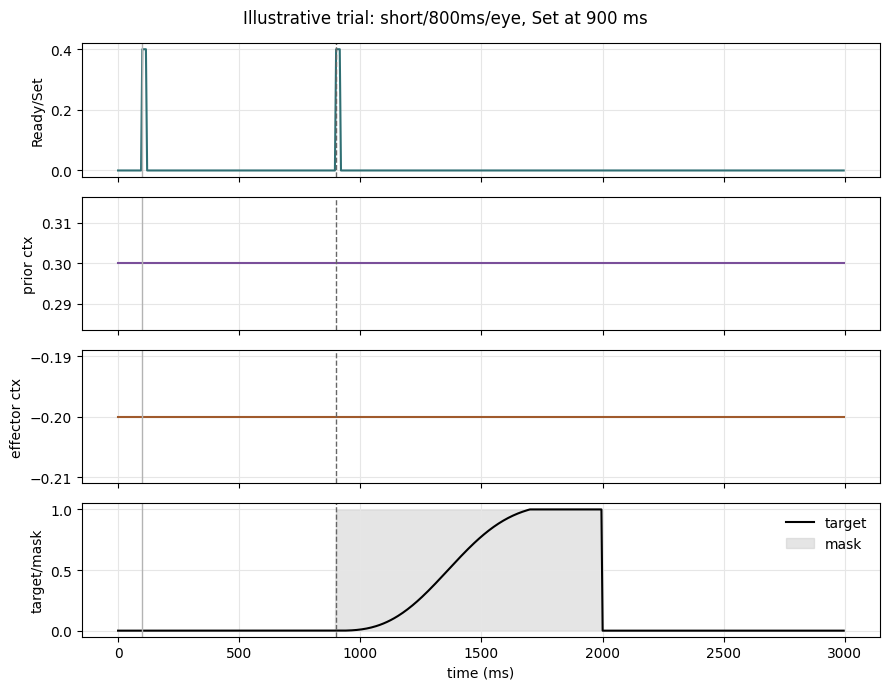

In [3]:
example_cond = next(c for c in CONDITIONS if c.prior == 'short' and c.ts == 800 and c.effector == 'eye')
trial_inputs, set_step = build_trial(cfg, example_cond, jitter=False)
target, mask = trial_target_and_mask(cfg, example_cond, set_step)
time_ms = np.arange(cfg.n_steps) * cfg.dt

fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
axes[0].plot(time_ms, trial_inputs[0, :, 0], color='#2f6f73')
axes[0].set_ylabel('Ready/Set')
axes[1].plot(time_ms, trial_inputs[0, :, 1], color='#7a4f9a')
axes[1].set_ylabel('prior ctx')
axes[2].plot(time_ms, trial_inputs[0, :, 2], color='#a05a2c')
axes[2].set_ylabel('effector ctx')
axes[3].plot(time_ms, target, color='black', label='target')
axes[3].fill_between(time_ms, 0, mask, color='0.8', alpha=0.5, label='mask')
axes[3].set_ylabel('target/mask')
axes[3].set_xlabel('time (ms)')
axes[3].legend(frameon=False)
for ax in axes:
    ax.axvline(cfg.ready_onset, color='0.7', lw=1)
    ax.axvline(set_step * cfg.dt, color='0.4', lw=1, ls='--')
    ax.grid(True, color='0.9')
fig.suptitle(f'Illustrative trial: {example_cond.label}, Set at {set_step * cfg.dt:.0f} ms')
fig.tight_layout()
plt.show()

## 3. Monkey data: conceptual target only

**Conceptual / not yet ingested in this repo.** `src/data/build_neural.py` is still a `TODO(me)` stub and importing or running `dandi`, `pynwb`, or `nlb_tools` is out of scope for this notebook.

The intended neural target is DMFC_RSG from DANDI 000130 / the Neural Latents Benchmark. The local docstring records: 1 monkey, 1 session, 54 sorted units, about 1,289 trials, Ready/Set/Go events, and behavioral `tp`. The real dataset has 40 conditions: `prior 2 x ts 5 x effector 2 x direction 2`. Direction is to be averaged away to match the 20-condition model comparison schema.

References recorded in `AGENTS.md`: Sohn, Narain, Meirhaeghe & Jazayeri (2019), DANDI dandiset 000130, and the NLB `DMFC_RSG` dataset page.

## 4. The model

The PC arm uses the same continuous-time leaky-RNN forward architecture as the BPTT arm. The shared parameter groups are:

- `J`: recurrent weights.
- `B`: input weights for the three task channels.
- `c_x`: recurrent bias.
- `x0`: initial raw state.
- `w_o`: effector-specific readout weights.
- `c_z`: effector-specific readout biases.

The forward rollout returns scalar effector-gated outputs `[batch, time]` and rate-like states `[batch, time, units]`.

PC-specific learning lives in `PCRNN.infer_and_update`. Raw pre-activation value nodes are initialized by a deterministic forward sweep, then relaxed against temporal Euler prediction errors and masked output prediction errors. The scalar PC energy is half the sum of squared temporal errors plus half the sum of squared masked output errors. After value relaxation, local updates are computed for `J`, `B`, `c_x`, `x0`, `w_o`, and `c_z`.

The PC mechanism is ported from `BerenMillidge/PredictiveCodingBackprop` onto this project's shared leaky RNN. It is not the original Sohn et al. optimizer; the planning docs note the paper used Hessian-free BPTT. BPTT is the comparison arm and shares the architecture, but this notebook does not walk through BPTT training or results.

## 5. Validation, told honestly

PC-A was the rule-internal validation stage. `tests/test_pc_rnn.py` checks deterministic forward parity against BPTT, energy descent during value relaxation, finite updates and values, toy-task loss reduction, update-alignment reporting, and the reduced seed-0 stability regression.

PC-B then attempted a real single-seed reduced-regime RSG run. The first Stage C attempt raised a `FloatingPointError` from `infer_and_update`: non-finite PC inference values, energy, or updates. The recorded root cause was unbounded PC updates, especially the readout, exploding within about seven iterations. The narrow fix added explicit finite guards and joint update-norm clipping using `cfg.grad_clip`. The PC test suite was independently reverified afterward.

The run shown here is now at the configured reduced-regime endpoint (`n_iter=3000`), but it is still not a clean behavioral pass. The saved metrics report `0/20` valid threshold crossings and NaN slopes for both priors. The output scale remains below `cfg.threshold=1.0`, so there is still no usable `tp`-vs-`ts` behavioral read from this seed.

Constants still unvalidated against Sohn et al. 2019 in this repo: `w_m`, `threshold`, `ramp_a`, `ramp_A`, trial-duration numbers such as `total_time`/`ready_onset`/`prod_hold`, and PC hyperparameters `pc_inference_steps`/`pc_inference_lr`. They are config fields to record and sweep, not paper-verified facts.

In [4]:
losses = np.asarray(metrics['losses'], dtype=float)
slopes = metrics.get('slopes_by_prior', {})
latest_ckpt = sorted((RUN_DIR / 'checkpoints').glob('checkpoint_iter_*.pt'))[-1] if (RUN_DIR / 'checkpoints').exists() else None
latest_ckpt_name = latest_ckpt.name if latest_ckpt else 'none'

def fmt_float(x):
    try:
        xf = float(x)
    except (TypeError, ValueError):
        return str(x)
    return 'NaN' if not math.isfinite(xf) else f'{xf:.6g}'

print('Saved run summary')
print(f'- config n_iter: {cfg.n_iter}')
print(f'- metrics n_iter: {metrics.get("n_iter")}')
print(f'- latest checkpoint present: {latest_ckpt_name}')
print(f'- losses recorded: {losses.size}')
print(f'- first loss: {losses[0]:.6g}')
print(f'- final saved loss: {losses[-1]:.6g}')
print(f'- finite_loss: {metrics.get("finite_loss")}')
print(f'- valid_tp_count: {metrics.get("valid_tp_count")}/{len(CONDITIONS)}')
print(f'- slopes_by_prior: short={fmt_float(slopes.get("short"))}, long={fmt_float(slopes.get("long"))}')
if metrics.get('n_iter') != cfg.n_iter:
    print('NOTE: metrics.json is partial relative to config.yaml; plots below reflect the saved metrics/activations on disk.')

Saved run summary
- config n_iter: 3000
- metrics n_iter: 3000
- latest checkpoint present: checkpoint_iter_003000.pt
- losses recorded: 3000
- first loss: 0.247743
- final saved loss: 0.000475625
- finite_loss: True
- valid_tp_count: 0/20
- slopes_by_prior: short=NaN, long=NaN


## 6. Plotting and diagnostics from the real saved run

The following diagnostics are loaded from `results/runs/pc/seed_0000/metrics.json`, its `ActivationStore`, and the PNGs previously generated under `results/figures/`. They are descriptive diagnostics, not evidence across seeds.

Training loss curve (handoff-required summary): results\figures\pc_seed0000_training_loss.png exists=True


### Training loss curve (handoff-required summary)

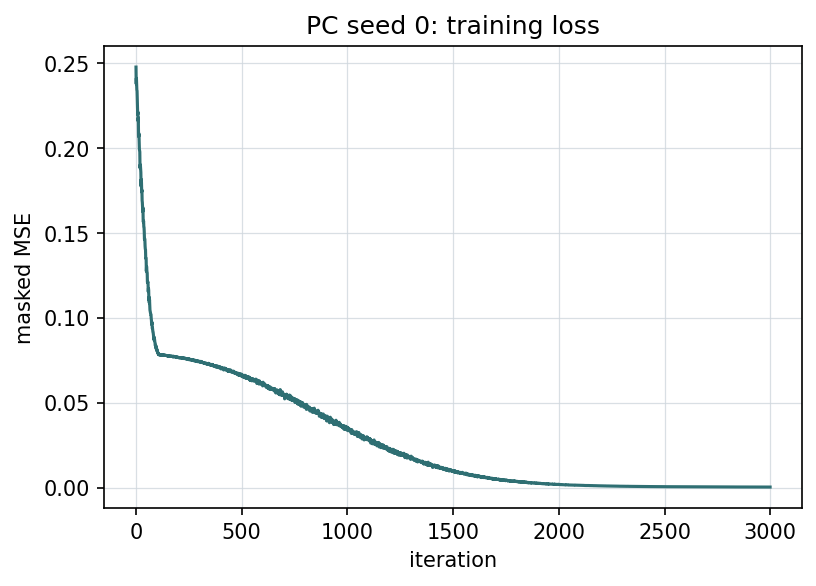

Behavior tp-vs-ts panel: results\figures\pc_seed0000_tp_vs_ts.png exists=True


### Behavior tp-vs-ts panel

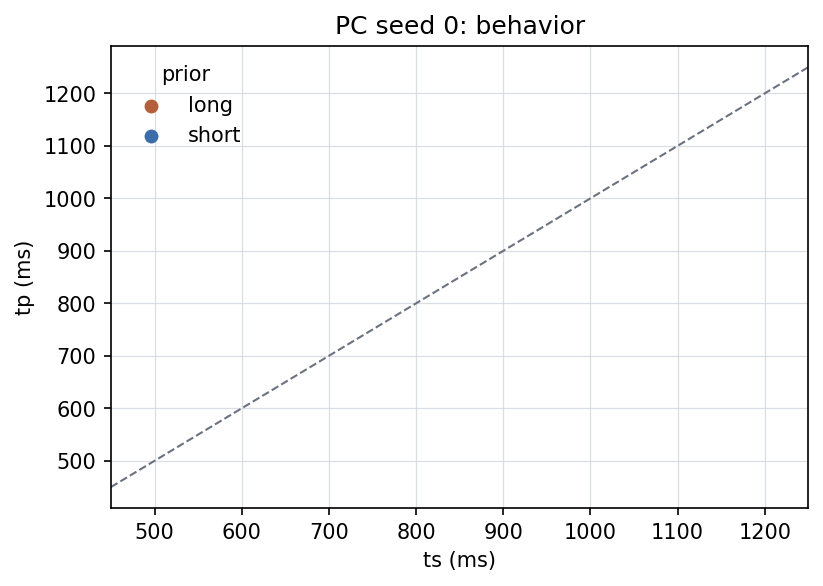

Training loss curve (activity script copy): results\figures\pc_activity\pc_training_loss.png exists=True


### Training loss curve (activity script copy)

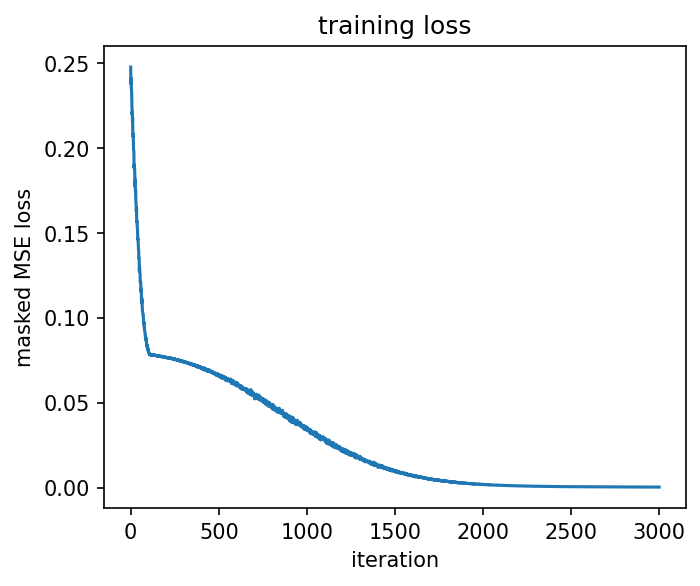

Unit activity for one condition: results\figures\pc_activity\pc_unit_activity.png exists=True


### Unit activity for one condition

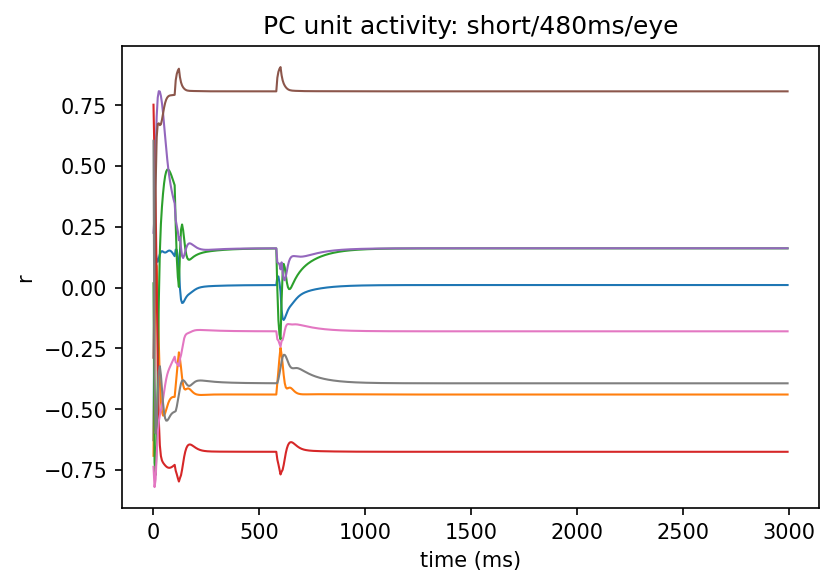

Output vs target ramp: results\figures\pc_activity\pc_output_vs_target.png exists=True


### Output vs target ramp

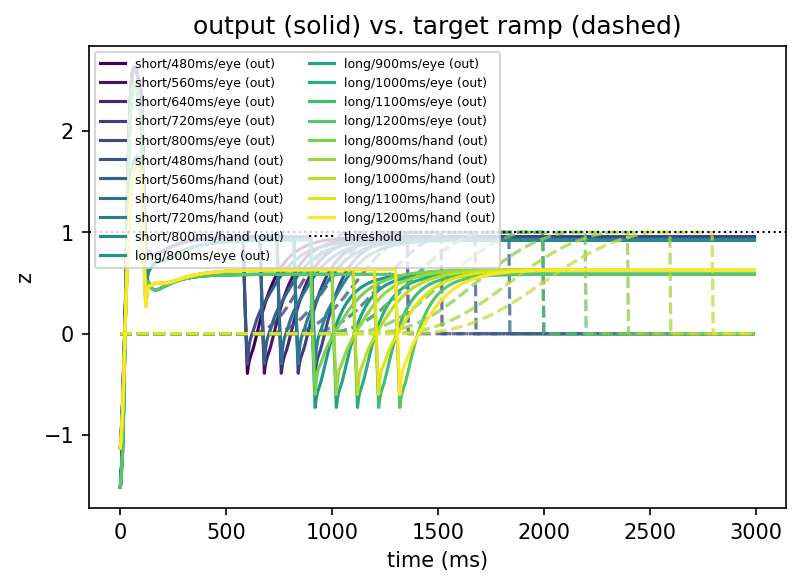

PCA trajectories by condition: results\figures\pc_activity\pc_pca_trajectories.png exists=True


### PCA trajectories by condition

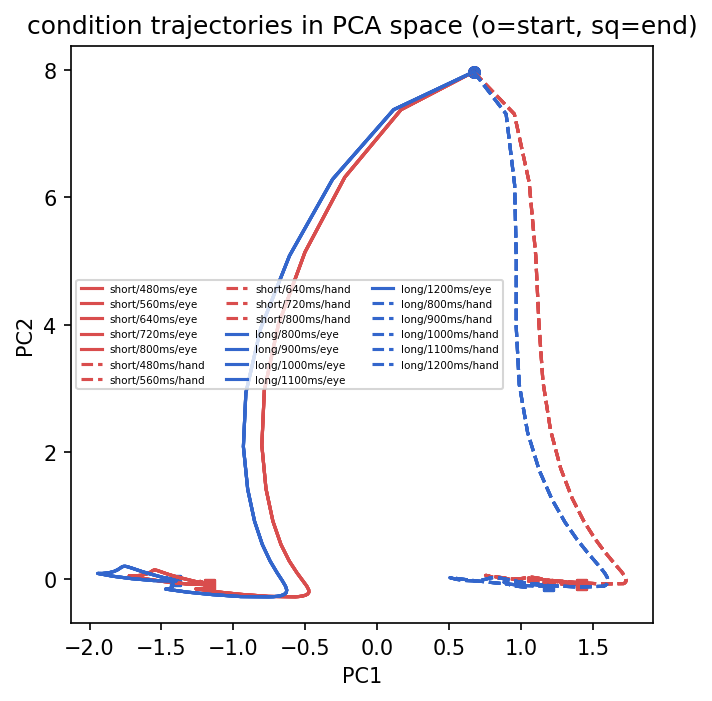

In [5]:
diagnostic_pngs = [
    ('Training loss curve (handoff-required summary)', FIG_DIR / 'pc_seed0000_training_loss.png'),
    ('Behavior tp-vs-ts panel', FIG_DIR / 'pc_seed0000_tp_vs_ts.png'),
    ('Training loss curve (activity script copy)', PC_FIG_DIR / 'pc_training_loss.png'),
    ('Unit activity for one condition', PC_FIG_DIR / 'pc_unit_activity.png'),
    ('Output vs target ramp', PC_FIG_DIR / 'pc_output_vs_target.png'),
    ('PCA trajectories by condition', PC_FIG_DIR / 'pc_pca_trajectories.png'),
]

for title, path in diagnostic_pngs:
    print(f'{title}: {path.relative_to(ROOT)} exists={path.exists()}')
    if path.exists():
        display(Markdown(f'### {title}'))
        display(Image(filename=str(path)))

How to read these panels:

- The training-loss curves show masked MSE-style loss from the saved metrics. The saved loss decreases strongly through the full 3000 configured iterations.
- The tp-vs-ts panel is empty because `valid_tp_count` is zero: no condition crossed threshold in the saved evaluation.
- Unit activity confirms the store contains nontrivial rate-like trajectories for a real condition.
- Output-vs-target shows the key caveat: the model output is under scale and does not cross `threshold=1.0` in the saved metrics.
- PCA trajectories are real stored states projected jointly across conditions. The current recorded interpretation is that trajectories separate cleanly by effector more than by prior; this is undertrained single-seed structure, not a learning-rule conclusion.

In [6]:
outputs = np.stack([rec.meta['outputs'] for rec in records.values()])
max_by_condition = {cond.key: float(np.nanmax(rec.meta['outputs'])) for cond, rec in records.items()}
print(f'output max range across stored conditions: {min(max_by_condition.values()):.4f} to {max(max_by_condition.values()):.4f}')
print(f'threshold: {cfg.threshold:.4f}')
print('first five condition output maxima:')
for key, value in list(max_by_condition.items())[:5]:
    print(f'  {key}: {value:.4f}')

output max range across stored conditions: 1.6710 to 2.6315
threshold: 1.0000
first five condition output maxima:
  short_ts0480_eye: 2.6315
  short_ts0560_eye: 2.6315
  short_ts0640_eye: 2.6315
  short_ts0720_eye: 2.6315
  short_ts0800_eye: 2.6315


## 7. Open items / where next

Open items intentionally preserved here:

- The reconstruction constants `w_m`, `threshold`, `ramp_a`, `ramp_A`, the trial-duration numbers, and PC inference hyperparameters remain unvalidated against the paper.
- Neural-data ingestion is future work. `src/data/build_neural.py` is a conceptual stub and needs the isolated ingestion environment.
- RSA/iDSA and DMFC comparisons are future-phase work. They require shared preprocessing and seed-level evidence.
- This notebook shows one PC seed and must not be treated as a seed-spread result.
- BPTT is only the architecture-matched comparison arm in this notebook; no BPTT result is presented here.

For continuation, start from `AGENTS.md`, the phase document `.suplex/phases/history/2026-07-20_pc_rnn_validation_and_rsg_smoke.md`, and the active SUPLEX handoff/report records.